# Hands-On 7: Clustering and feature-space geometry

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from mlcourse.labs import compare_clusters, cluster_summary
from mlcourse.widgets import interactive_clustering
from mlcourse.labs import cluster_plot

## 1. Compare three partitions of a toy dataset

Load the eight points. Compare K-Means, DBSCAN and single-linkage clustering. K-Means uses Euclidean geometry while the other two use Manhattan distance here.

**Prediction:** Can density connectivity recover a different structure from centroid assignment?

Yes. Density connectivity depends on local neighbourhood support while centroid assignment depends on distance to centres.

,A1,A2
id,,
p1,4,4
p2,0,2
p3,4,3
p4,0,0
p5,5,4
p6,1,1
p7,2,0
p8,5,5


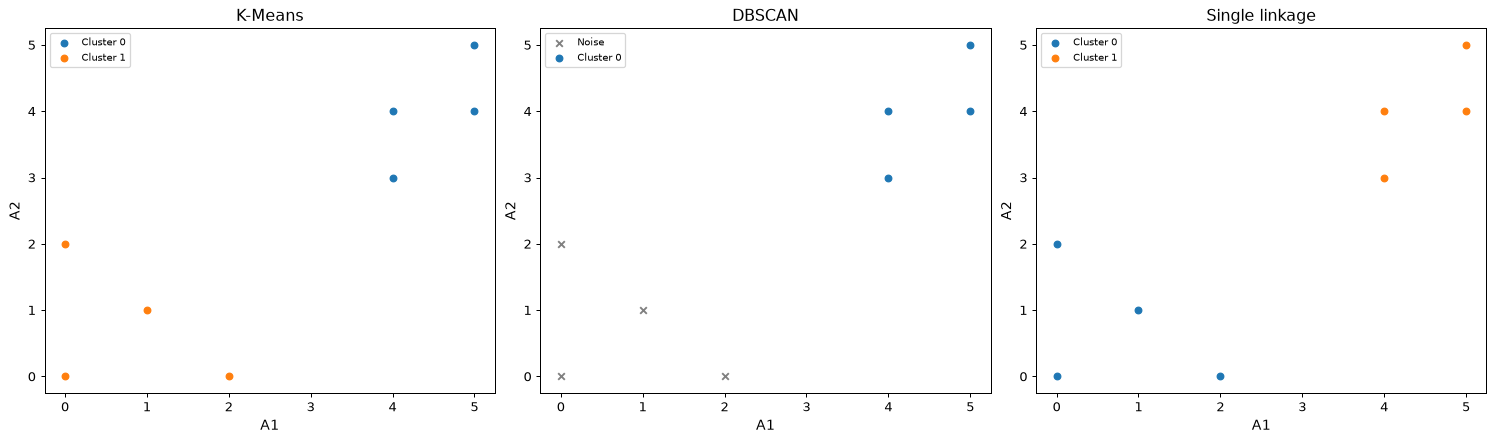

,clusters,noise_count,silhouette
model,,,
K-Means,2,0,0.681
DBSCAN,1,4,NaN
Single linkage,2,0,0.681


In [3]:
toy = load_course_data('toy').set_index('id')[['A1', 'A2']]
toy_models = {'K-Means': KMeans(n_clusters=2, init=toy.loc[['p1', 'p6']].to_numpy(), n_init=1, random_state=0),
              'DBSCAN': DBSCAN(eps=1, min_samples=2, metric='manhattan'),
              'Single linkage': AgglomerativeClustering(n_clusters=2, linkage='single', metric='manhattan')}
display(toy)
display(compare_clusters(toy_models, toy))

**Observation:** Compare cluster membership and any noise points.

K-Means and single linkage produce the same two groups here, up to arbitrary label numbers. DBSCAN groups the four upper-right points and marks the other four as noise.

**Explanation:** Explain the three rules without relying on the arbitrary cluster numbers.

K-Means assigns points to centroids and updates those centroids. DBSCAN connects supported neighbourhoods, and single linkage merges groups through their closest points.

## 2. Scale a real feature space

Load Wholesale data and select `Grocery` and `Milk`. Compare K-Means before and after standardisation.

**Prediction:** How can feature scale influence Euclidean distances?

The coordinate with a larger numerical spread can dominate Euclidean distances.

,Grocery,Milk
0,7561,9656
1,9568,9810
2,7684,8808
3,4221,1196
4,7198,5410


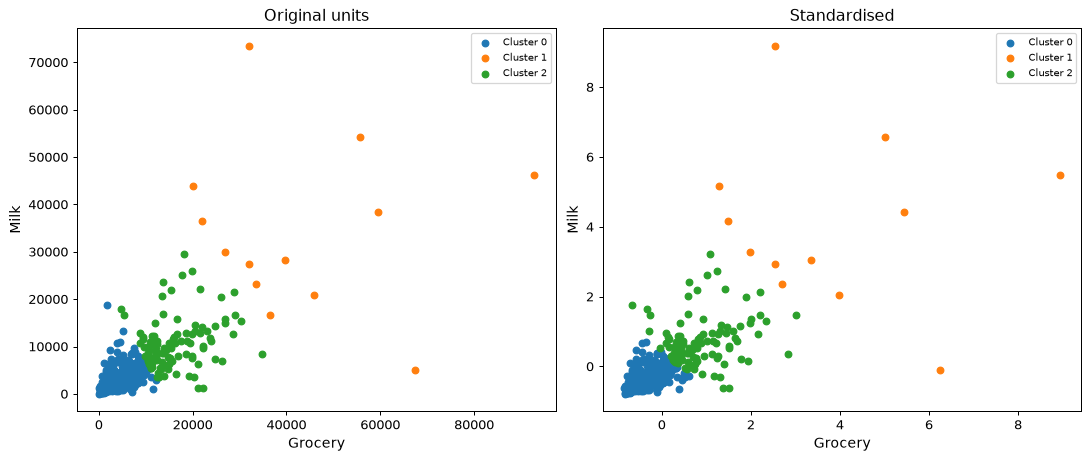

Scaled cluster,0,1,2
Original cluster,,,
0,317,0,3
1,0,12,1
2,9,0,98


In [4]:
wholesale = load_course_data('wholesale')
raw = wholesale[['Grocery', 'Milk']]
scaled = pd.DataFrame(StandardScaler().fit_transform(raw), columns=raw.columns, index=raw.index)
display(raw.head())
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
memberships = {}
for ax, values, name in zip(axes, [raw, scaled], ['Original units', 'Standardised']):
    labels = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(values)
    memberships[name] = labels
    cluster_plot(ax, values, labels, name)
plt.show()
display(pd.crosstab(pd.Series(memberships['Original units'], name='Original cluster'),
                    pd.Series(memberships['Standardised'], name='Scaled cluster')))

**Observation:** Locate points whose membership changes.

The membership cross-tabulation shows 12 boundary moves from original clusters 0 and 2, plus one from original cluster 1. Most observations remain in the corresponding groups after scaling.

**Explanation:** Why is scaling part of the clustering assumptions?

Standardisation changes the relative distance contribution of each feature. It therefore changes the geometry on which clustering operates.

## 3. Explore cluster number

Compare `n_clusters` from `2` to `8` using inertia and silhouette.

**Prediction:** Must inertia decrease when more centroids are available?

The best achievable inertia cannot increase with additional centroids. Numerical optimisation may still find different local solutions.

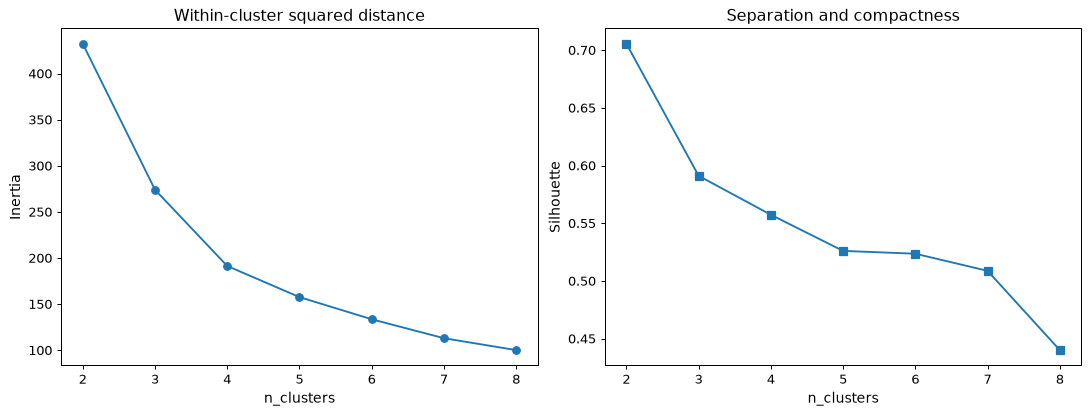

,n_clusters,inertia,silhouette
0,2,432.393,0.706
1,3,274.062,0.591
2,4,191.350,0.557
3,5,157.594,0.526
4,6,133.555,0.524
5,7,113.023,0.509
6,8,100.098,0.440


In [5]:
rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(scaled)
    rows.append({'n_clusters': k, 'inertia': model.inertia_, **cluster_summary(scaled, model.labels_)})
cluster_scores = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
axes[0].plot(cluster_scores.n_clusters, cluster_scores.inertia, '-o')
axes[1].plot(cluster_scores.n_clusters, cluster_scores.silhouette, '-s')
axes[0].set(xlabel='n_clusters', ylabel='Inertia', title='Within-cluster squared distance')
axes[1].set(xlabel='n_clusters', ylabel='Silhouette', title='Separation and compactness')
plt.show()
display(cluster_scores[['n_clusters', 'inertia', 'silhouette']])

**Observation:** Compare the elbow suggestion with the largest silhouette.

Silhouette is highest at `n_clusters=2`, with 0.706, and decreases to 0.440 at `8`. Inertia gains become smaller after roughly three or four clusters, making the elbow less decisive than the silhouette maximum.

**Explanation:** Why can the two criteria suggest different choices?

Inertia rewards compactness without directly penalising extra clusters. Silhouette contrasts within-cluster distance with distance to another cluster.

## 4. Inspect density clustering

Fit DBSCAN with `eps=0.500` and `min_samples=5` on the scaled data.

**Prediction:** What kinds of points are likely to be marked as noise?

Isolated observations in sparse regions are more likely to lack sufficient neighbourhood support.

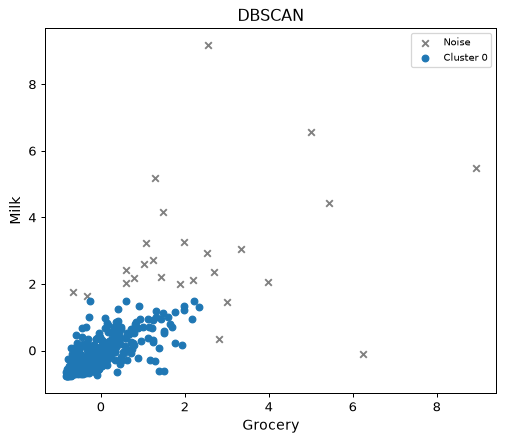

,clusters,noise_count,silhouette
model,,,
DBSCAN,1,25,NaN


In [6]:
display(compare_clusters({'DBSCAN': DBSCAN(eps=.5, min_samples=5)}, scaled))

**Observation:** Count the clusters and noise observations.

DBSCAN finds one cluster and 25 noise observations. Silhouette is undefined here because only one non-noise cluster remains.

**Explanation:** Explain how `eps` and `min_samples` define local support.

`eps` defines the neighbourhood radius and `min_samples` its required support, including the point itself. The displayed silhouette excludes noise and describes only assigned observations.

## 5. Inspect hierarchical merging

Plot a truncated single-linkage dendrogram. Compare complete-linkage clustering in the laboratory below.

**Prediction:** What does a high merge in the dendrogram indicate?

A high merge joins groups that are farther apart under the chosen linkage rule.

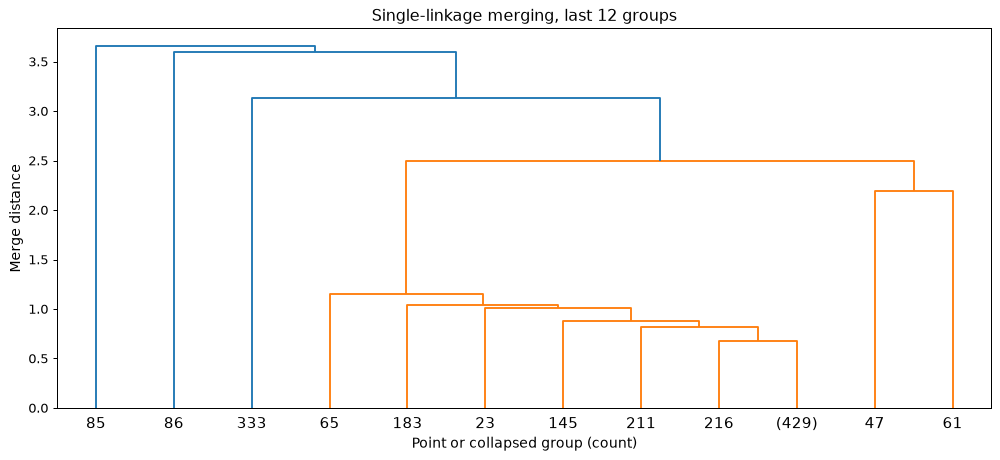

In [7]:
merges = linkage(scaled, method='single', metric='euclidean')
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
dendrogram(merges, truncate_mode='lastp', p=12, show_leaf_counts=True, ax=ax)
ax.set(xlabel='Point or collapsed group (count)', ylabel='Merge distance', title='Single-linkage merging, last 12 groups')
plt.show()

**Observation:** Identify a large change in merge distance.

One long vertical branch extends from about 1.200 to 2.500 before its next merge. The leaf labelled `(429)` condenses a large group, while the other displayed leaves identify individual observations.

**Explanation:** How would complete linkage change the meaning of inter-cluster distance?

Single linkage uses the closest cross-cluster pair and can chain observations. Complete linkage uses the farthest cross-cluster pair, favouring more compact groups.

## 6. Compare full-feature partitions

Use the six spending measurements, then display their partitions in two principal components. Inspect one compact profile table.

**Prediction:** Will a two-dimensional projection preserve every separation in six dimensions?

No. Projection can hide separation along the four omitted directions.

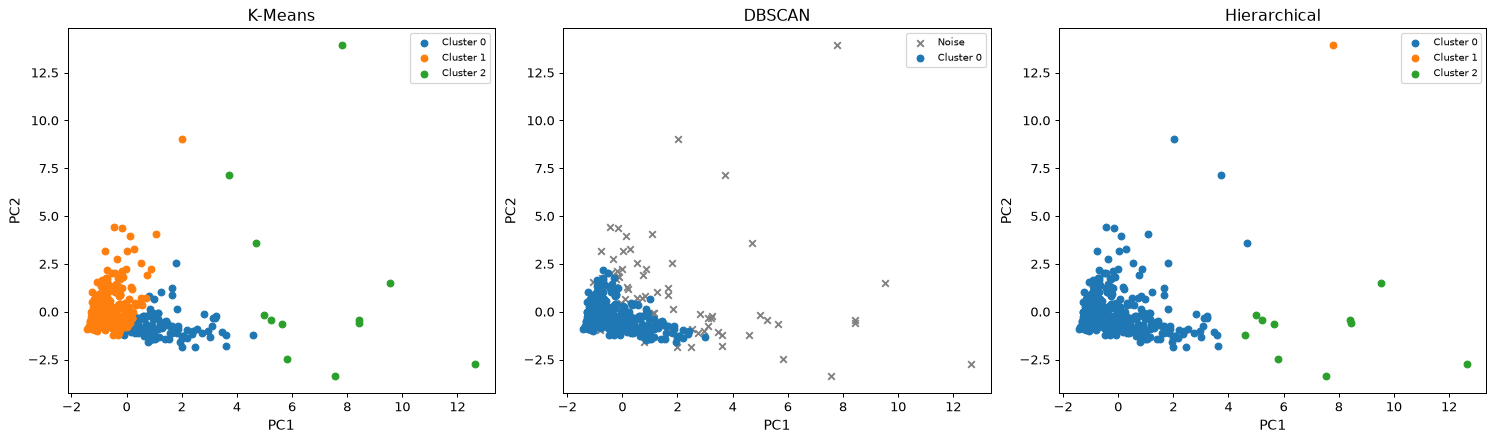

,clusters,noise_count,silhouette
model,,,
K-Means,3,0,0.343
DBSCAN,1,74,NaN
Hierarchical,3,0,0.712


Variance displayed: 0.725


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,-0.501,0.603,0.876,-0.346,0.875,0.083
1,0.117,-0.346,-0.423,0.081,-0.418,-0.118
2,1.233,4.043,3.717,0.851,3.604,2.450


In [8]:
spending = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
full_scaled = StandardScaler().fit_transform(wholesale[spending])
pca = PCA(n_components=2).fit(full_scaled)
projection = pd.DataFrame(pca.transform(full_scaled), columns=['PC1', 'PC2'])
full_models = {'K-Means': KMeans(n_clusters=3, n_init=10, random_state=0),
               'DBSCAN': DBSCAN(eps=.8, min_samples=5),
               'Hierarchical': AgglomerativeClustering(n_clusters=3, linkage='complete')}
display(compare_clusters(full_models, full_scaled, projection))
print(f'Variance displayed: {pca.explained_variance_ratio_.sum():.3f}')
labels = full_models['K-Means'].fit_predict(full_scaled)
profiles = pd.DataFrame(full_scaled, columns=spending).groupby(labels).mean()
display(profiles)

**Observation:** Compare projected overlap and standardised profiles.

The two components display 0.725 of the standardised variance. K-Means cluster 2 has particularly high Milk and Grocery coordinates in the profile table, but the projection still hides 0.275 of the variance.

**Explanation:** Why should the silhouette use the fitted feature space rather than the display coordinates?

The algorithms were fitted using six-dimensional distances, so that is the space their silhouettes assess. Two-component plots are partial views of those partitions.

## 7. Manipulate clustering assumptions

Change `n_clusters`, DBSCAN neighbourhood parameters and hierarchical linkage on the same two-feature data.

**Prediction:** Which algorithm can leave observations unassigned?

DBSCAN can mark observations as noise; K-Means and agglomerative clustering assign all observations.

In [9]:
clustering_lab = interactive_clustering(scaled)
display(clustering_lab.widget)

**Observation:** Record one change in cluster membership and one change in noise count.

Changing K-Means from two to four clusters splits its broad groups and changes silhouette from 0.706 to 0.557. With DBSCAN and `min_samples=5`, increasing `eps` from 0.500 to 1.000 reduces noise from 25 observations to 8.

**Explanation:** Explain which geometric assumption caused each change.

Centroid count changes the K-Means partition; density thresholds change connectivity and support. Hierarchical linkage changes how distances between groups are defined.